# Experiment 4: MobileNetV3-Small — End-to-End Transfer Learning
**Method:** MobileNetV3-Small pre-trained on ImageNet, fine-tuned on PlantVillage (38 classes)

**Instance:** ml.g4dn.xlarge (1x T4 GPU, 16GB VRAM, 16GB RAM) or higher

**Memory-safe:** Uses tf.data batch loading — only 32 images in RAM at a time

**Assumes data is already downloaded** in `./data/`

In [1]:
# ---- CELL 1: Install deps + fix libdevice (MUST run before anything else) ----
import subprocess, os

# Install nvidia-cuda-nvcc which contains libdevice.10.bc
subprocess.run(['pip', 'install', '-q', 'tensorflow', 'nvidia-cuda-nvcc-cu12'], check=True)

# Find where libdevice.10.bc was installed
result = subprocess.run(
    ['find', '/opt/conda', '-name', 'libdevice.10.bc', '-type', 'f'],
    capture_output=True, text=True
)
found = [p for p in result.stdout.strip().split('\n') if p]

if found:
    # Point XLA to the PARENT directory that contains nvvm/libdevice/
    # libdevice.10.bc is at: .../nvidia/cuda_nvcc/nvvm/libdevice/libdevice.10.bc
    # XLA expects: {cuda_data_dir}/nvvm/libdevice/libdevice.10.bc
    # So cuda_data_dir = everything BEFORE /nvvm/libdevice/
    libdevice_path = found[0]
    # Go up: libdevice.10.bc -> libdevice/ -> nvvm/ -> cuda_nvcc/
    cuda_data_dir = os.path.dirname(os.path.dirname(os.path.dirname(libdevice_path)))
    os.environ['XLA_FLAGS'] = f'--xla_gpu_cuda_data_dir={cuda_data_dir}'
    print(f'Found libdevice at: {libdevice_path}')
    print(f'Set XLA cuda_data_dir to: {cuda_data_dir}')
else:
    print('WARNING: libdevice.10.bc not found after install!')
    # Last resort: try to symlink with sudo
    subprocess.run(['sudo', 'mkdir', '-p', '/usr/local/cuda/nvvm/libdevice'], check=False)
    result2 = subprocess.run(
        ['find', '/', '-name', 'libdevice.10.bc', '-type', 'f'],
        capture_output=True, text=True, timeout=30
    )
    all_found = [p for p in result2.stdout.strip().split('\n') if p]
    if all_found:
        subprocess.run(['sudo', 'ln', '-sf', all_found[0], '/usr/local/cuda/nvvm/libdevice/libdevice.10.bc'])
        print(f'Symlinked with sudo: {all_found[0]}')

print('libdevice fix applied. Proceed to next cell.')

Found libdevice at: /opt/conda/lib/python3.12/site-packages/triton/backends/nvidia/lib/libdevice.10.bc
Set XLA cuda_data_dir to: /opt/conda/lib/python3.12/site-packages/triton/backends
libdevice fix applied. Proceed to next cell.


In [2]:
import os, glob, yaml
import numpy as np
import tensorflow as tf

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

# ---- Load class names from YAML ----
yaml_files = glob.glob("./data/**/*.yaml", recursive=True)
with open(yaml_files[0], "r") as f:
    data_config = yaml.safe_load(f)
class_names = data_config["names"]
NUM_CLASSES = len(class_names)
print(f"Classes: {NUM_CLASSES}")

# ---- Find image and label folders ----
image_folders = []
for root, dirs, _ in os.walk("./data"):
    for d in dirs:
        if d == "images":
            image_folders.append(os.path.join(root, d))
print(f"Image folders: {image_folders}")

2026-03-03 06:00:32.978784: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 06:00:32.991795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772517633.009423   17006 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772517633.014800   17006 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-03 06:00:33.031861: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

TensorFlow: 2.18.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Classes: 38
Image folders: ['./data/PlantVillage_for_object_detection/Dataset/images']


In [3]:
# ---- Build (image_path, label_index) pairs without loading images ----

def get_class_from_label(label_path, class_names):
    if not os.path.exists(label_path):
        return None
    with open(label_path, "r") as f:
        lines = f.readlines()
    if not lines:
        return None
    class_ids = []
    for line in lines:
        parts = line.strip().split()
        if parts:
            try:
                class_ids.append(int(parts[0]))
            except ValueError:
                continue
    if not class_ids:
        return None
    return max(set(class_ids), key=class_ids.count)

# Collect all (path, label_index) pairs
all_paths = []
all_labels = []

for img_folder in image_folders:
    label_folder = img_folder.replace("images", "labels")
    if not os.path.exists(label_folder):
        continue
    print(f"Scanning: {img_folder}")
    for img_file in sorted(os.listdir(img_folder)):
        if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        img_path = os.path.join(img_folder, img_file)
        label_file = os.path.splitext(img_file)[0] + ".txt"
        label_path = os.path.join(label_folder, label_file)
        cls_idx = get_class_from_label(label_path, class_names)
        if cls_idx is None or cls_idx >= NUM_CLASSES:
            continue
        all_paths.append(img_path)
        all_labels.append(cls_idx)

print(f"\nTotal valid samples: {len(all_paths)}")
print(f"Memory used: just file paths, no images loaded yet")

Scanning: ./data/PlantVillage_for_object_detection/Dataset/images

Total valid samples: 54293
Memory used: just file paths, no images loaded yet


In [4]:
# ---- Train/Test Split (on paths, not images) ----
from sklearn.model_selection import train_test_split

paths_train, paths_test, labels_train, labels_test = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)
print(f"Train: {len(paths_train)}, Test: {len(paths_test)}")

Train: 43434, Test: 10859


In [5]:
# ---- tf.data pipeline (loads images in batches, not all at once) ----
IMG_SIZE = 224
BATCH_SIZE = 32

def load_and_preprocess(path, label):
    """Load one image from disk, resize, normalize."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # img = img / 255.0  # MobileNetV3 expects [0,255]! removed normalization
    return img, label

# Training dataset with shuffle and prefetch
train_ds = tf.data.Dataset.from_tensor_slices(
    (paths_train, labels_train)
)
train_ds = train_ds.shuffle(10000)
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

# Test dataset (no shuffle)
test_ds = tf.data.Dataset.from_tensor_slices(
    (paths_test, labels_test)
)
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print(f"Train batches: {len(paths_train) // BATCH_SIZE}")
print(f"Test batches: {len(paths_test) // BATCH_SIZE}")
print(f"Memory: only {BATCH_SIZE} images loaded at a time")

Train batches: 1357
Test batches: 339
Memory: only 32 images loaded at a time


I0000 00:00:1772517638.059592   17006 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [6]:
# ---- Build MobileNetV3-Small with Transfer Learning ----
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models

# Load pre-trained base (no classification head)
# Data Augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
], name="data_augmentation")

base_model = MobileNetV3Small(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False  # freeze all base layers

# Classification head
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()
trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"\nTrainable params: {trainable:,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        21,926 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961,046 (3.67 MB)

 Trainable params: 21,926 (85.65 KB)

 Non-trainable params: 939,120 (3.58 MB)


Trainable params: 21,926


In [7]:
# ---- Phase 1: Train classification head only (base frozen) ----
print("Phase 1: Training classification head (base frozen)...")

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
)

Phase 1: Training classification head (base frozen)...
Epoch 1/10


I0000 00:00:1772517645.950911   17065 cuda_dnn.cc:529] Loaded cuDNN version 91002


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.7663 - loss: 0.8887 - val_accuracy: 0.8944 - val_loss: 0.3786
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.8915 - loss: 0.3825 - val_accuracy: 0.9203 - val_loss: 0.2712
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.9046 - loss: 0.3137 - val_accuracy: 0.9203 - val_loss: 0.2535
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.9122 - loss: 0.2812 - val_accuracy: 0.9300 - val_loss: 0.2213
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.9186 - loss: 0.2624 - val_accuracy: 0.9347 - val_loss: 0.2072
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.9206 - loss: 0.2504 - val_accuracy: 0.9326 - val_loss: 0.2063
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.9207 - loss: 0.2463 - val_accuracy: 0.9387 - val_loss: 0.1898
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.9219 - loss: 0.23

In [8]:
# ---- Phase 2: Fine-tune top layers ----
print("Phase 2: Fine-tuning top 30 layers of MobileNetV3...")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
)

Phase 2: Fine-tuning top 30 layers of MobileNetV3...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 54s 33ms/step - accuracy: 0.9056 - loss: 0.3132 - val_accuracy: 0.9463 - val_loss: 0.1663
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9494 - loss: 0.1541 - val_accuracy: 0.9678 - val_loss: 0.1027
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9623 - loss: 0.1167 - val_accuracy: 0.9697 - val_loss: 0.0973
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9689 - loss: 0.0943 - val_accuracy: 0.9732 - val_loss: 0.0838
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9734 - loss: 0.0791 - val_accuracy: 0.9700 - val_loss: 0.0941
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9760 - loss: 0.0710 - val_accuracy: 0.9798 - val_loss: 0.0645
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9785 - loss: 0.0629 - val_accuracy: 0.9775 - val_loss: 0.0683
Epoch 8/10
1358/1358 ━━

In [9]:
# ---- Results ----
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test set
y_true = []
y_pred = []
for images_batch, labels_batch in test_ds:
    preds = model.predict(images_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels_batch.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)
print(f"\n{'='*50}")
print(f"  ACCURACY: {accuracy:.2%}")
print(f"{'='*50}")

# Convert to class names
y_true_names = [class_names[i] for i in y_true]
y_pred_names = [class_names[i] for i in y_pred]

report = classification_report(y_true_names, y_pred_names)
print(f"\nClassification Report:\n")
print(report)

with open("classification_report_mobilenet.txt", "w") as f:
    f.write(f"Accuracy: {accuracy:.2%}\n\n")
    f.write(f"Model: MobileNetV3-Small (transfer learning, fine-tuned)\n")
    f.write(f"Dataset: PlantVillage YOLO | Samples: {len(all_paths)}\n")
    f.write(f"Train: {len(paths_train)}, Test: {len(paths_test)}\n")
    f.write(f"Image size: {IMG_SIZE}x{IMG_SIZE} | Batch: {BATCH_SIZE} | Epochs: 10+10\n\n")
    f.write(report)
print("Saved classification_report_mobilenet.txt")


  ACCURACY: 98.13%

Classification Report:

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.99      0.97      0.98       126
                            Apple___Black_rot       0.98      1.00      0.99       124
                     Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                              Apple___healthy       0.98      0.98      0.98       329
                          Blueberry___healthy       1.00      1.00      1.00       300
                      Cherry___Powdery_mildew       1.00      1.00      1.00       210
                             Cherry___healthy       1.00      1.00      1.00       171
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.88      0.85       103
                           Corn___Common_rust       1.00      1.00      1.00       238
                  Corn___Northern_Leaf_Blight       0.94      0.91      0.93       1

2026-03-03 06:14:29.589290: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


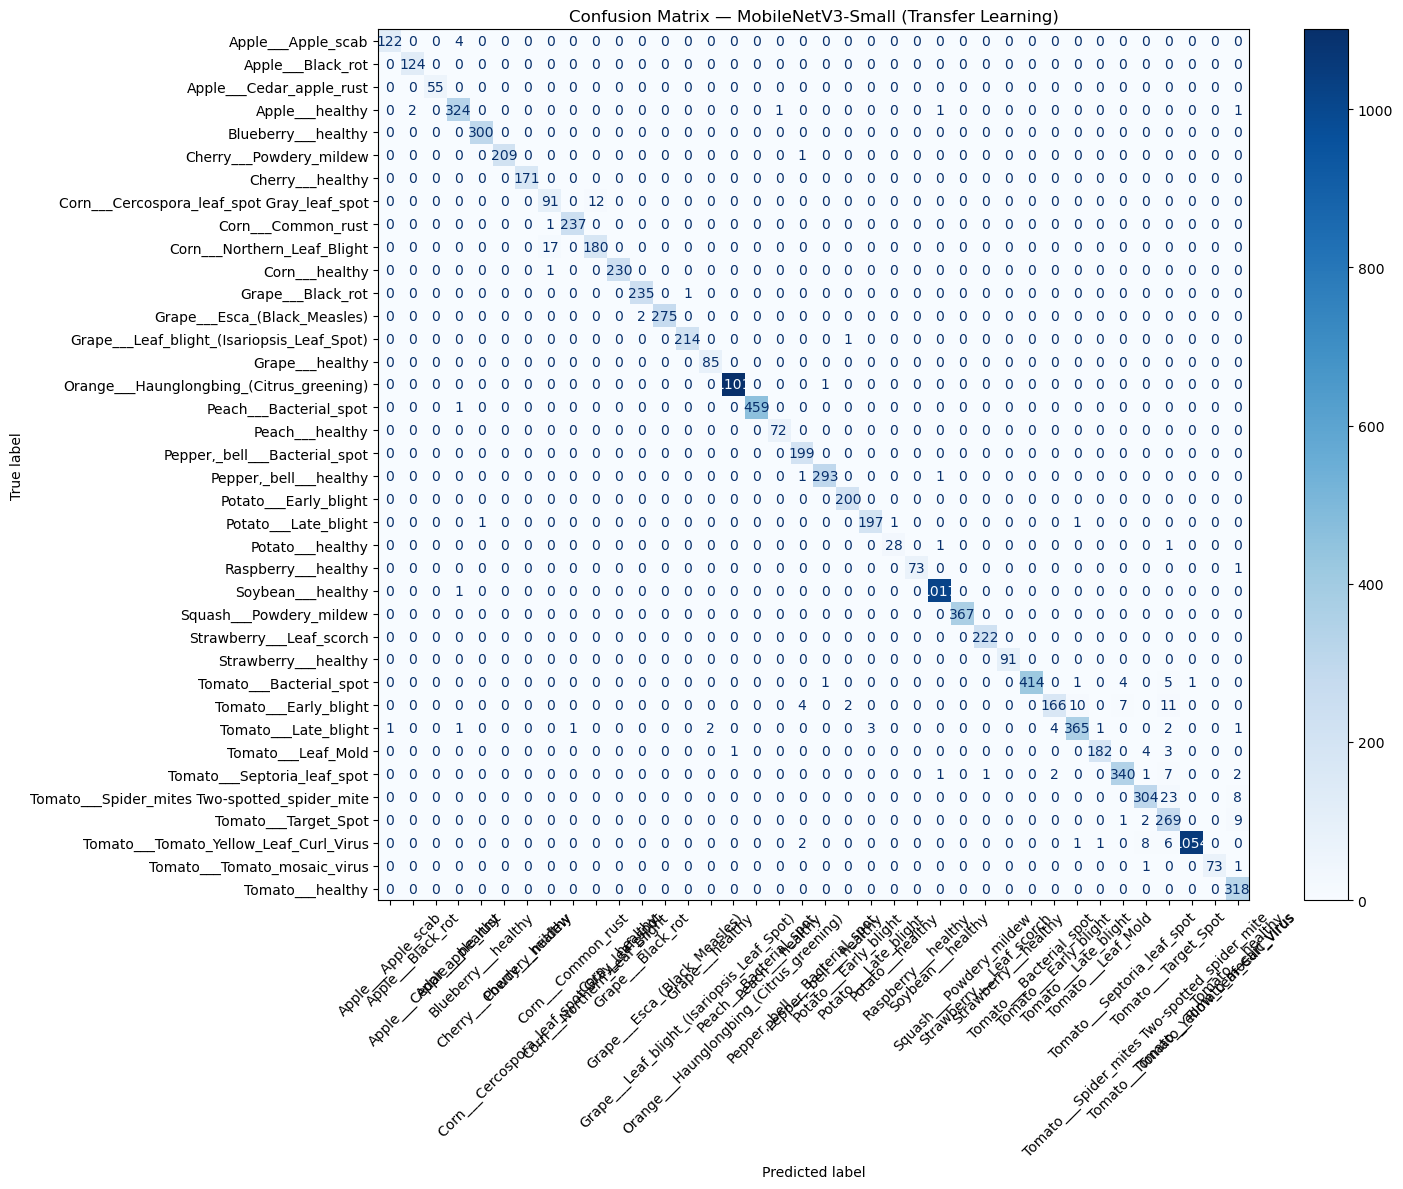

Saved confusion_matrix_mobilenet.png


In [10]:
# ---- Confusion Matrix ----
cm = confusion_matrix(y_true_names, y_pred_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(15, 12))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — MobileNetV3-Small (Transfer Learning)")
plt.tight_layout()
plt.savefig("confusion_matrix_mobilenet.png", dpi=150)
plt.show()
print("Saved confusion_matrix_mobilenet.png")

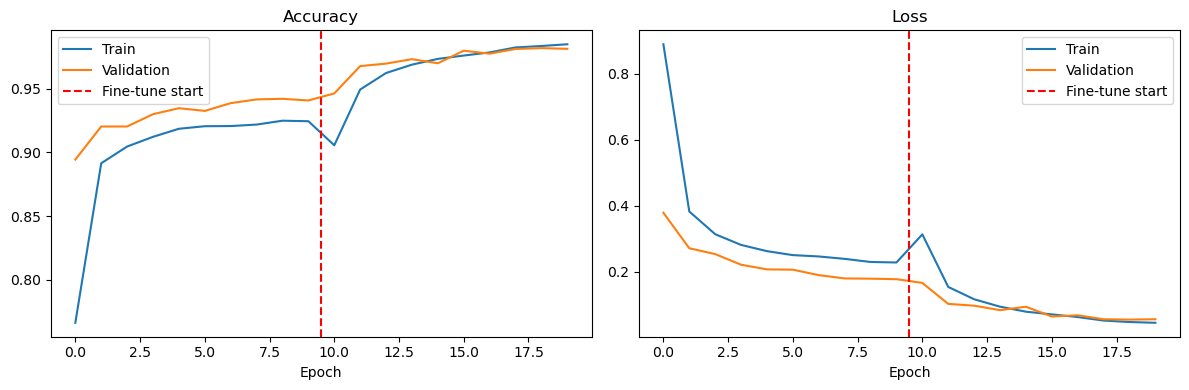

Saved training_curves_mobilenet.png


In [11]:
# ---- Training Curves ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

all_acc = history.history["accuracy"] + history_fine.history["accuracy"]
all_val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]
all_loss = history.history["loss"] + history_fine.history["loss"]
all_val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

ax1.plot(all_acc, label="Train")
ax1.plot(all_val_acc, label="Validation")
ax1.axvline(x=9.5, color="red", linestyle="--", label="Fine-tune start")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(all_loss, label="Train")
ax2.plot(all_val_loss, label="Validation")
ax2.axvline(x=9.5, color="red", linestyle="--", label="Fine-tune start")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig("training_curves_mobilenet.png", dpi=150)
plt.show()
print("Saved training_curves_mobilenet.png")

In [12]:
# ---- Save model (.h5 and .tflite for edge deployment) ----

# Keras model
model.save("mobilenet_leaf_disease.h5")
h5_size = os.path.getsize("mobilenet_leaf_disease.h5") / (1024 * 1024)
print(f"Saved mobilenet_leaf_disease.h5 ({h5_size:.1f} MB)")

# TFLite (quantized for edge)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("mobilenet_leaf_disease.tflite", "wb") as f:
    f.write(tflite_model)

tflite_size = os.path.getsize("mobilenet_leaf_disease.tflite") / (1024 * 1024)
print(f"Saved mobilenet_leaf_disease.tflite ({tflite_size:.1f} MB)")

Saved mobilenet_leaf_disease.h5 (8.7 MB)
INFO:tensorflow:Assets written to: /tmp/tmpug0ega6m/assets


INFO:tensorflow:Assets written to: /tmp/tmpug0ega6m/assets


Saved artifact at '/tmp/tmpug0ega6m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_175')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  140075600171216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140075600174096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140075600173904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140075600173328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140075600172752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140075600173712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140075600175056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140075600174864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140075600174480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140075600175632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140075600

W0000 00:00:1772518480.788978   17006 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772518480.789013   17006 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-03-03 06:14:40.789402: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpug0ega6m
2026-03-03 06:14:40.802044: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-03 06:14:40.802092: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpug0ega6m
I0000 00:00:1772518480.890396   17006 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2026-03-03 06:14:40.911356: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-03 06:14:41.568060: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpug0ega6m
2026-03-03 06:14:41.729542: I tensorflow/cc/saved_model/loader.cc:466] SavedModel 

In [13]:
# ---- Save class names for deployment ----
import json
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print(f"\n{'='*50}")
print(f"DONE! Output files:")
print(f"{'='*50}")
print(f"  mobilenet_leaf_disease.h5          ({h5_size:.1f} MB) — Keras model")
print(f"  mobilenet_leaf_disease.tflite      ({tflite_size:.1f} MB) — Edge deployment")
print(f"  class_names.json                   — Class name mapping")
print(f"  classification_report_mobilenet.txt — Per-class metrics")
print(f"  confusion_matrix_mobilenet.png     — Visual results")
print(f"  training_curves_mobilenet.png      — Training history")


DONE! Output files:
  mobilenet_leaf_disease.h5          (8.7 MB) — Keras model
  mobilenet_leaf_disease.tflite      (1.1 MB) — Edge deployment
  class_names.json                   — Class name mapping
  classification_report_mobilenet.txt — Per-class metrics
  confusion_matrix_mobilenet.png     — Visual results
  training_curves_mobilenet.png      — Training history
